In [2]:
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import sys
import os
# === Add project path if needed ===


# -----------------------------
# Red-agent → ID mapping
# -----------------------------
red_agent_names = [
    "CybORG.Agents.SimpleAgents.ConstantAgent.SleepAgent",
    "FSRedAgentCombined.FSRedAgentCombined",
    "FSRedAgentDegrader.FSRedAgentDegrader",
    "FSRedAgentFailureTracker.FSRedAgentFailureTracker",
    "FSRedAgentImpacter.FSRedAgentImpacter",
    "FSRedAgentTargetA.FSRedAgentTargetA",
    "FSRedAgentTargetAOperational.FSRedAgentTargetAOperational",
    "FSRedAgentTargetARestricted.FSRedAgentTargetARestricted",
    "FSRedAgentTargetB.FSRedAgentTargetB",
    "FSRedAgentTargetBOperational.FSRedAgentTargetBOperational",
    "FSRedAgentTargetBRestricted.FSRedAgentTargetBRestricted",
    "CybORG.Agents.SimpleAgents.FiniteStateRedAgent.FiniteStateRedAgent",
    "FSMultipleSwitchAgent1.FSMultipleSwitchAgent1",
]

attacker_name_to_id = {name: i for i, name in enumerate(red_agent_names)}
NUM_ATTACKERS = len(red_agent_names)



In [3]:

def read_belief_log(
    belief_file,
    num_episodes=100,
    episode_length=500,
    num_attackers=12,
):
    beliefs = np.zeros(
        (num_episodes, episode_length, num_attackers),
        dtype=np.float32
    )
    attack_ids = -np.ones(num_episodes, dtype=np.int32)

    class_pattern = re.compile(r"<class '([^']+)'>")

    with open(belief_file, "r") as f:
        lines = f.readlines()

    ep_idx = -1
    for line in lines:
        line = line.strip()

        # Skip headers
        if line.startswith("CybORG") or line.startswith("Author"):
            continue

        if line.startswith("Episode"):
            ep_idx += 1
            if ep_idx >= num_episodes:
                break

            raw = line.split("beliefs:", 1)[1].strip()

            # 🔧 FIX: replace <class 'X'> with 'X'
            sanitized = class_pattern.sub(r"'\1'", raw)

            try:
                ep_beliefs = ast.literal_eval(sanitized)
            except Exception as e:
                raise RuntimeError(
                    f"Failed parsing episode {ep_idx}\n"
                    f"Original: {raw[:200]}...\n"
                    f"Sanitized: {sanitized[:200]}..."
                ) from e

            for entry in ep_beliefs:
                t = entry["t"]
                belief_vec = np.asarray(entry["belief"], dtype=np.float32)

                if t >= episode_length:
                    continue

                beliefs[ep_idx, t, :] = belief_vec

                if attack_ids[ep_idx] == -1:
                    attacker_name = "FSMultipleSwitchAgent1.FSMultipleSwitchAgent1"
                    attack_ids[ep_idx] = attacker_name_to_id[attacker_name]
            print(attacker_name)


    return beliefs, attack_ids


In [4]:
beliefs, attack_ids = read_belief_log("belief_log.txt")

print(beliefs.shape)     # (100, 500, 12)
print(attack_ids.shape) # (100,)
print("traj 0 belief:" + str(beliefs[0]))
print(attack_ids)
# print(np.unique(attack_ids))


FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleSwitchAgent1
FSMultipleSwitchAgent1.FSMultipleS

In [5]:
import matplotlib.pyplot as plt

def plot_predicted_attacker(beliefs, attack_ids, traj_idx=0):
    pred = beliefs[traj_idx].argmax(axis=1)

    plt.figure(figsize=(10, 4))
    plt.plot(pred, label="Predicted attacker (argmax belief)")
    plt.axhline(
        attack_ids[traj_idx],
        color="red",
        linestyle="--",
        label="True attacker"
    )
    plt.xlim([0,498])
    plt.xlabel("Time step")
    plt.ylabel("Attacker ID")
    plt.title(f"Trajectory {traj_idx}")
    plt.legend()
    plt.tight_layout()
    plt.show()


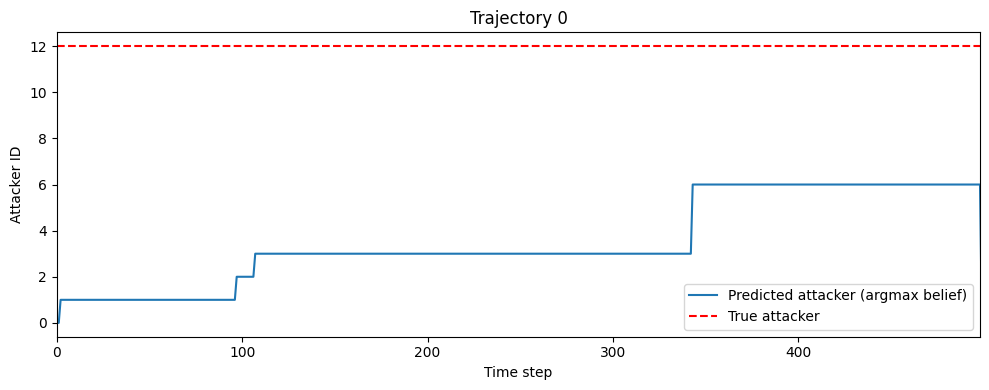

In [6]:
plot_predicted_attacker(beliefs, attack_ids, traj_idx=0)

In [7]:
traj_idx = 0
pred = beliefs[traj_idx,:,attack_ids[traj_idx]]

plt.figure(figsize=(10, 4))
plt.plot(pred)
plt.xlim([0,498])
plt.xlabel("Time step")
plt.ylabel("True Attack Probability Predicted")
plt.title(f"Trajectory {traj_idx}")
plt.legend()
plt.tight_layout()
plt.show()


IndexError: index 12 is out of bounds for axis 2 with size 12

In [8]:

pred = np.zeros(beliefs[traj_idx,:,attack_ids[0]].shape)
for traj_idx in range(100):
    pred += beliefs[traj_idx,:,attack_ids[traj_idx]]
pred /= 100

print(pred.mean())

plt.figure(figsize=(10, 4))
plt.plot(pred)
plt.xlim([0,498])
plt.xlabel("Time step")
plt.ylabel("Average True Attack Probability Predicted")
# plt.title(f"Trajectory {traj_idx}")
plt.legend()
plt.tight_layout()
plt.show()


IndexError: index 12 is out of bounds for axis 2 with size 12

In [9]:

pred = np.zeros(beliefs[traj_idx,:,attack_ids[0]].shape)
for traj_idx in range(100):
    pred += beliefs[traj_idx,:,attack_ids[traj_idx]]
pred /= 100

print(pred.mean())

plt.figure(figsize=(10, 4))
plt.plot(pred)
plt.xlim([0,498])
plt.xlabel("Time step")
plt.ylabel("Average True Attack Probability Predicted")
# plt.title(f"Trajectory {traj_idx}")
plt.legend()
plt.tight_layout()
plt.show()


IndexError: index 12 is out of bounds for axis 2 with size 12

In [10]:
pred = beliefs[0].argmax(axis=1)
for i in range(1,99):
    pred+=
print(pred)

plt.figure(figsize=(10, 4))
plt.plot(pred.mean(axis=1), label="Predicted attacker (argmax belief)")
plt.axhline(
    attack_ids[traj_idx],
    color="red",
    linestyle="--",
    label="True attacker"
)
plt.xlim([0,498])
plt.xlabel("Time step")
plt.ylabel("Attacker ID")
plt.title(f"Trajectory {traj_idx}")
plt.legend()
plt.tight_layout()
plt.show()


SyntaxError: invalid syntax (4155970290.py, line 3)

In [11]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

T = beliefs.shape[1]
A = beliefs.shape[2]


for att_type in range(A):
    # Select trajectories with this true attacker
    idxs = np.where(attack_ids == att_type)[0]

    if len(idxs) == 0:
        continue

    # Average belief over those trajectories
    # shape: [T, A]
    mean_belief = beliefs[idxs].mean(axis=0)

for att_type in range(A):
    idxs = np.where(attack_ids == att_type)[0]
    if len(idxs) == 0:
        continue

    mean_belief = beliefs[idxs].mean(axis=0)  # [T, A]

    plt.figure(figsize=(12, 4))
    sns.heatmap(
        mean_belief.T,
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=True
    )

    plt.xlabel("Time step")
    plt.ylabel("Belief index")
    plt.title(f"Belief evolution heatmap | True attacker = {att_type}")

    plt.tight_layout()
    plt.show()


(100, 500, 12)


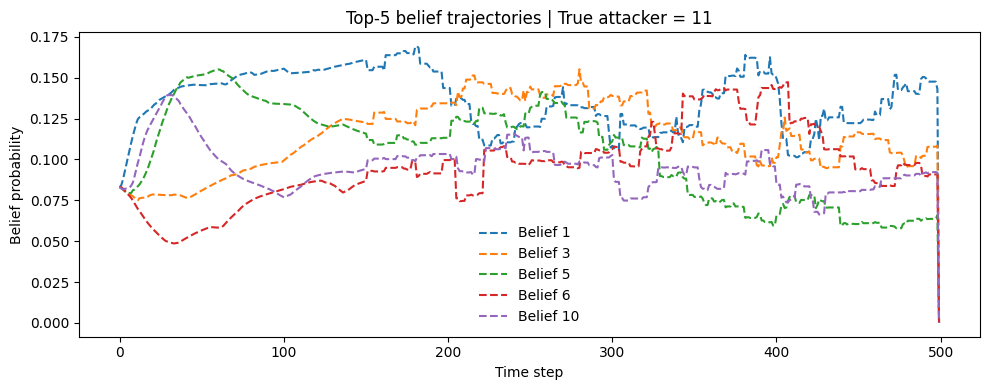

In [12]:
top_k = 5 # change to 5 if you want richer dynamics
# for att_type in range(12):
print(beliefs.shape)
mean_belief = beliefs.mean(axis=0)  # [T, A]
# print(mean_belief)
# Top-k belief indices by time-averaged mass
top_idxs = np.argsort(mean_belief.mean(axis=0))[-top_k:][::-1]

plt.figure(figsize=(10, 4))

for j in top_idxs:
    style = "-" if j == att_type else "--"
    lw = 3 if j == att_type else 1.5

    plt.plot(
        mean_belief[:, j],
        linestyle=style,
        linewidth=lw,
        label=f"Belief {j}"
    )

plt.xlabel("Time step")
plt.ylabel("Belief probability")
# plt.ylim([0, 1])
plt.title(f"Top-{top_k} belief trajectories | True attacker = {att_type}")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


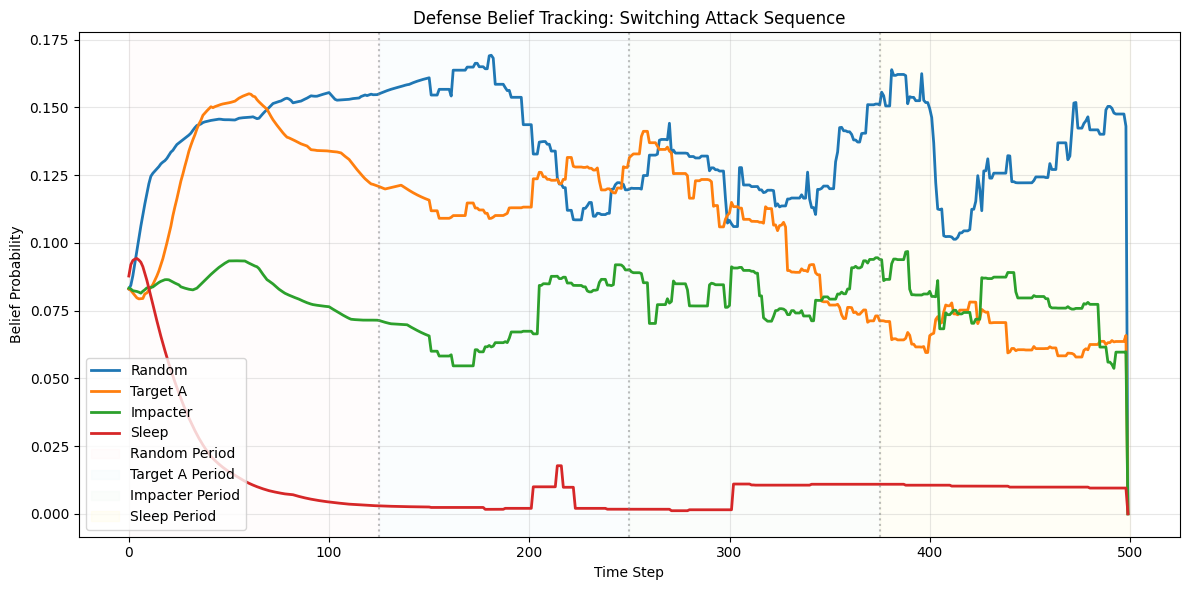

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Red-agent → ID mapping
red_agent_names = [
    "CybORG.Agents.SimpleAgents.ConstantAgent.SleepAgent",
    "FSRedAgentCombined.FSRedAgentCombined",
    "FSRedAgentDegrader.FSRedAgentDegrader",
    "FSRedAgentFailureTracker.FSRedAgentFailureTracker",
    "FSRedAgentImpacter.FSRedAgentImpacter",
    "FSRedAgentTargetA.FSRedAgentTargetA",
    "FSRedAgentTargetAOperational.FSRedAgentTargetAOperational",
    "FSRedAgentTargetARestricted.FSRedAgentTargetARestricted",
    "FSRedAgentTargetB.FSRedAgentTargetB",
    "FSRedAgentTargetBOperational.FSRedAgentTargetBOperational",
    "FSRedAgentTargetBRestricted.FSRedAgentTargetBRestricted",
    "CybORG.Agents.SimpleAgents.FiniteStateRedAgent.FiniteStateRedAgent",
]

attacker_name_to_id = {name: i for i, name in enumerate(red_agent_names)}

# The 4 attackers in switching sequence
switching_sequence = [
    ("FSRedAgentCombined.FSRedAgentCombined", "Random", 0, 125),      # Period 1
    ("FSRedAgentTargetA.FSRedAgentTargetA", "Target A", 125, 250),     # Period 2
    ("FSRedAgentImpacter.FSRedAgentImpacter", "Impacter", 250, 375),   # Period 3
    ("CybORG.Agents.SimpleAgents.ConstantAgent.SleepAgent", "Sleep", 375, 500)  # Period 4
]

# Get IDs for these agents
agent_ids = [attacker_name_to_id[name] for name, _, _, _ in switching_sequence]
agent_labels = [label for _, label, _, _ in switching_sequence]

# Load your beliefs (shape: [episodes, T, A])
# beliefs = ... # Load your belief data here
# Assuming beliefs is already loaded

mean_belief = beliefs.mean(axis=0)  # [T, A] - average across episodes

# Plot
plt.figure(figsize=(12, 6))

for idx, (agent_id, label, start, end) in zip(agent_ids, switching_sequence):
    # # print(idx)
    # print(agent_id)
    plt.plot(
        mean_belief[:, idx],
        linewidth=2,
        label=f"{label}"
    )

# Add vertical lines at transition points
for _, _, start, _ in switching_sequence[1:]:  # Skip first start (0)
    plt.axvline(x=start, color='gray', linestyle=':', alpha=0.5)

# Shade background by period
colors = ['#ffebee', '#e3f2fd', '#e8f5e9', '#fff9c4']
for i, (_, label, start, end) in enumerate(switching_sequence):
    plt.axvspan(start, end, alpha=0.15, color=colors[i], label=f"{label} Period")

plt.xlabel("Time Step")
plt.ylabel("Belief Probability")
plt.title("Defense Belief Tracking: Switching Attack Sequence")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

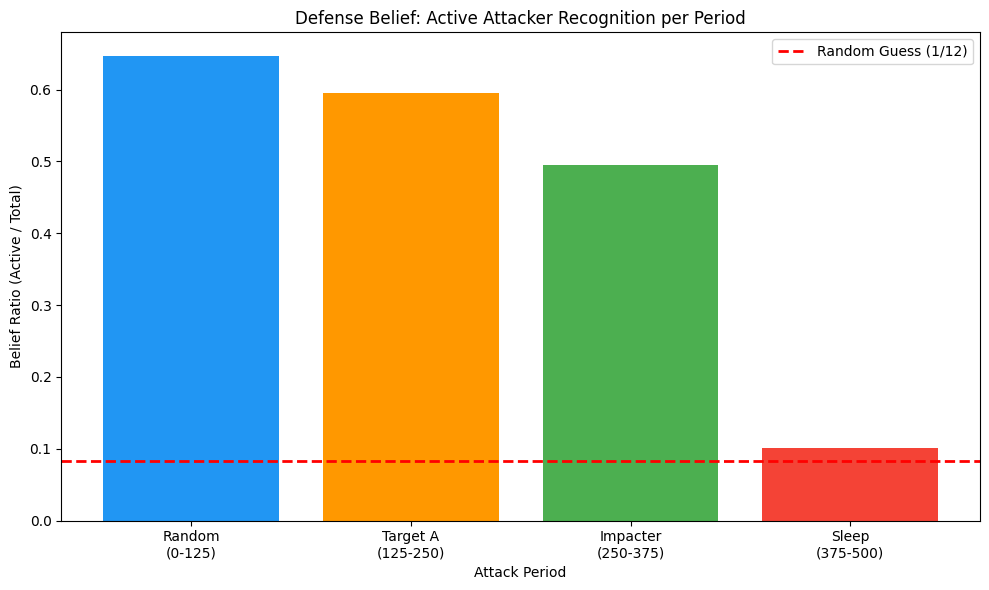

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate relative belief strength for active attacker in each period
periods = [(0, 125, 1), (125, 250, 5), (250, 375, 4), (375, 500, 0)]  # (start, end, agent_id)
active_agent_ids = [1, 5, 4, 0]  # Random, TargetA, Impacter, Sleep

period_labels = ["Random\n(0-125)", "Target A\n(125-250)", "Impacter\n(250-375)", "Sleep\n(375-500)"]
relative_strengths = []

for start, end, active_id in periods:
    period_beliefs = mean_belief[start:end, :]
    active_belief = period_beliefs[:, active_id].mean()
    other_beliefs = np.delete(period_beliefs, active_id, axis=1).mean()
    ratio = active_belief / (active_belief + other_beliefs)
    relative_strengths.append(ratio)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(4), relative_strengths, color=['#2196F3', '#FF9800', '#4CAF50', '#F44336'])
plt.axhline(y=1/12, color='red', linestyle='--', linewidth=2, label='Random Guess (1/12)')
plt.xlabel("Attack Period")
plt.ylabel("Belief Ratio (Active / Total)")
plt.xticks(range(4), period_labels)
plt.title("Defense Belief: Active Attacker Recognition per Period")
plt.legend()
plt.tight_layout()
plt.show()

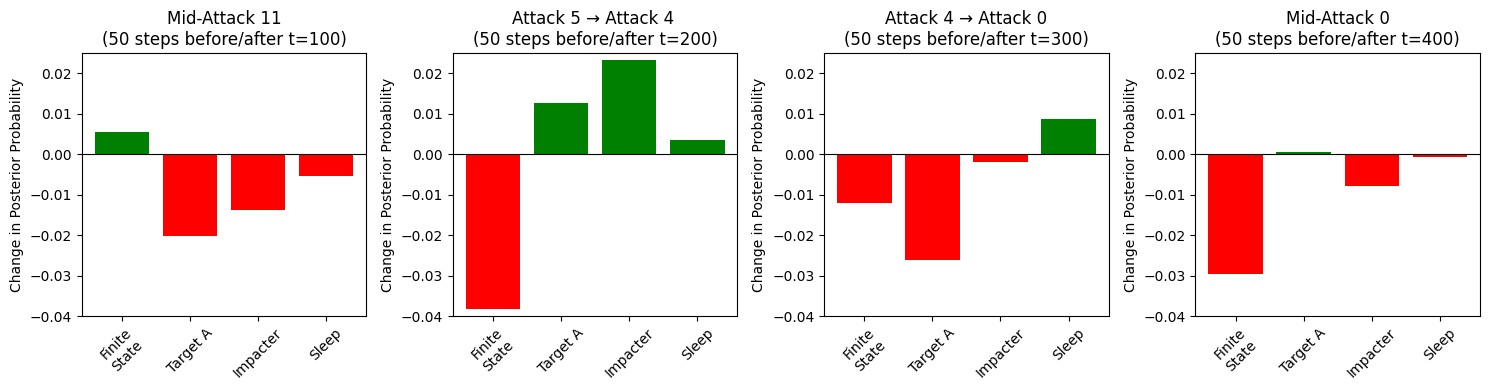

In [15]:
# Calculate belief jumps at transition points
transition_points = [100, 200, 300, 400]
window = 100  # Look 10 steps before/after transition
period_titles = [
    "Mid-Attack 11\n(50 steps before/after t=100)",
    "Attack 5 → Attack 4 \n(50 steps before/after t=200)",
    "Attack 4 → Attack 0\n(50 steps before/after t=300)",
    "Mid-Attack 0\n(50 steps before/after t=400)"
]
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
agent_labels = ["Finite\nState", "Target A", "Impacter", "Sleep"]
i = 0
for idx, (trans_point, ax, title) in enumerate(zip(transition_points, axes, period_titles)):
    if i == 0:
        window_a = 50; window_b=50
    elif i == 1:
        window_a = 50; window_b=50
    elif i == 2:
        window_a = 50; window_b=50
    else:
        window_a = 50; window_b=50
        
    i += 1
    before = mean_belief[trans_point-window_b:trans_point, agent_ids]
    after = mean_belief[trans_point:trans_point+window_a, agent_ids]
    
    delta = after.mean(axis=0) - before.mean(axis=0)
    
    colors = ['green' if d > 0 else 'red' for d in delta]
    ax.bar(agent_labels, delta, color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("Change in Posterior Probability")
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim([-0.04,0.025])

plt.tight_layout()
plt.savefig("res5.jpg", dpi=180)
plt.show()

In [ ]:
# Calculate rank of correct attacker at each timestep
correct_sequence = [1]*125 + [5]*125 + [4]*125 + [0]*125  # Agent IDs per timestep
ranks = []

for t in range(500):
    sorted_beliefs = np.argsort(mean_belief[t, :])[::-1]  # Descending order
    correct_id = correct_sequence[t]
    rank = np.where(sorted_beliefs == correct_id)[0][0] + 1  # 1-indexed rank
    ranks.append(rank)

plt.figure(figsize=(12, 5))
plt.plot(ranks, linewidth=2, color='#2196F3')
plt.axhline(y=1, color='green', linestyle='--', label='Rank 1 (Best)')
plt.axhline(y=6, color='orange', linestyle='--', label='Rank 6 (Median)')

# Period backgrounds
colors = ['#ffebee', '#e3f2fd', '#e8f5e9', '#fff9c4']
labels = ['Finite State', 'Target A', 'Impacter', 'Sleep']
for i, (start, end) in enumerate([(0,125), (125,250), (250,375), (375,500)]):
    plt.axvspan(start, end, alpha=0.2, color=colors[i])

plt.xlabel("Time Step")
plt.ylabel("Rank of Correct Attacker (1=Best)")
plt.ylim([12, 0])  # Inverted: lower rank = better
plt.title("Defense Tracking: Rank of Active Attacker")
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()